# Notebook 2: Simulation of Brownian Motion and Application in Finance

**Objective:** Simulate trajectories of Brownian Motion (BM) and use it as a basis to build a pricing model for financial assets, the Geometric Brownian Motion (GBM). We will visualize how the drift (μ) and volatility (σ) parameters affect price behavior.

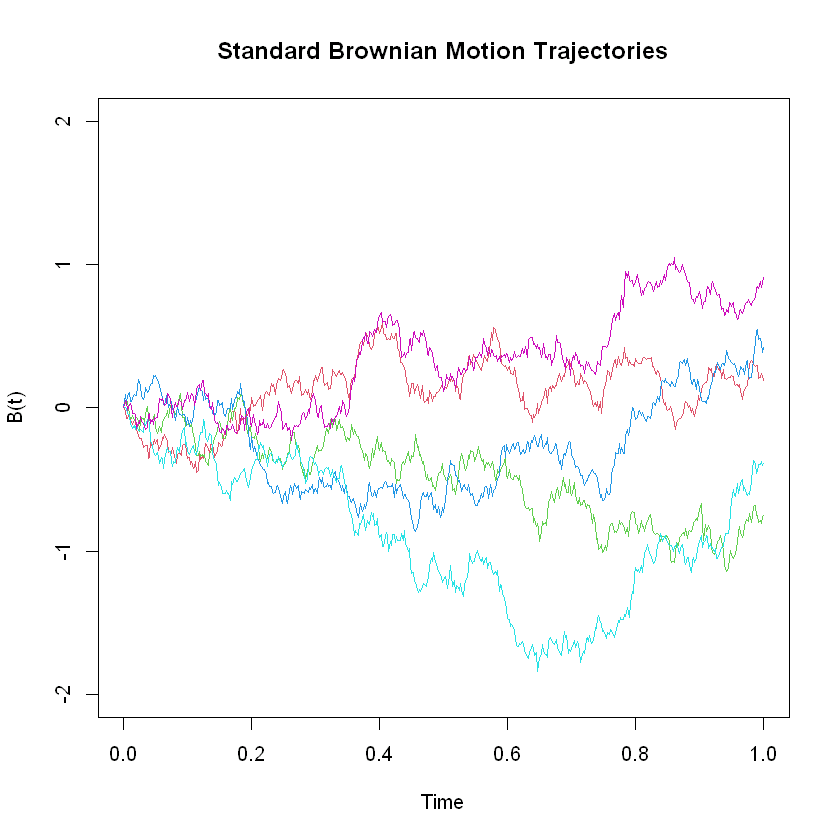

In [3]:
# Step 1: Simulate trajectories of Brownian Motion (BM)
#
# BM is simulated by generating small increments that follow a normal distribution:
# B(t_i+1) - B(t_i) ~ N(0, dt) 
# The complete process is obtained by cumulatively summing these increments.

# Set seed
set.seed(1000)

simulate_bm <- function(T_final, n_steps) {
  dt <- T_final / n_steps
  # Generate normal increments
  increments <- rnorm(n_steps, mean = 0, sd = sqrt(dt))
  # Cumulative sum to obtain the trajectory, starting from 0
  path <- c(0, cumsum(increments))
  return(path)
}

# Parameters
T_final <- 1.0 # 1-year time horizon
n_steps <- 500
time <- seq(0, T_final, length.out = n_steps + 1)

# Simulate and plot several trajectories
plot(NULL, xlim = c(0, T_final), ylim = c(-2, 2),
     main = "Standard Brownian Motion Trajectories",
     xlab = "Time", ylab = "B(t)")

for (i in 1:5) {
  bm_path <- simulate_bm(T_final, n_steps)
  lines(time, bm_path, col = i + 1)
}

### Step 2: Implement Geometric Brownian Motion (GBM)

GBM is a standard model for the evolution of asset prices (such as stocks) that cannot be negative. Its formula is:

$\displaystyle S_{t}=S_{0}exp((\mu-\frac{\sigma^{2}}{2})t+\sigma B_{t})$

Where:
- $S_0$: Initial price of the asset.
- $\mu$ (mu): Drift rate or expected return.
- $\sigma$ (sigma): Asset volatility.
- $B_t$: A standard Brownian Motion.

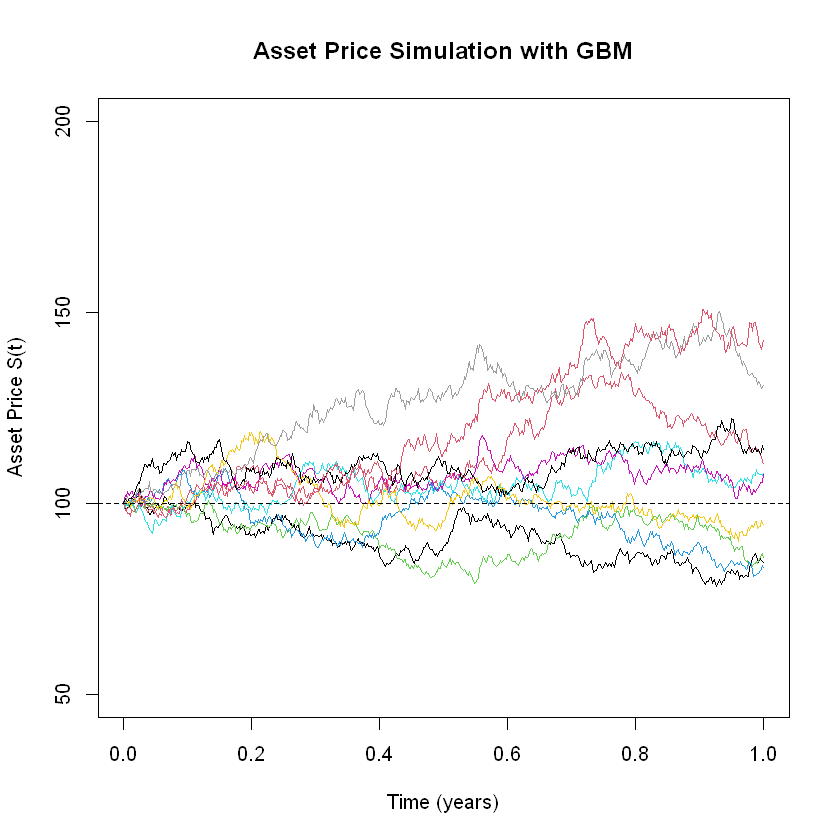

In [4]:
# Step 2: GBM Simulation

simulate_gbm <- function(S0, mu, sigma, T_final, n_steps) {
  dt <- T_final / n_steps
  time <- seq(0, T_final, length.out = n_steps + 1)
  
  # First, we simulate the underlying Brownian Motion
  bm_path <- simulate_bm(T_final, n_steps)
  
  # Apply the GBM formula
  price <- S0 * exp((mu - 0.5 * sigma^2) * time + sigma * bm_path)
  return(price)
}

# Financial parameters
S0 <- 100    # Initial price
mu <- 0.05   # 5% annual drift
sigma <- 0.2 # 20% annual volatility

# Simulate and plot several price trajectories
plot(NULL, xlim = c(0, T_final), ylim = c(50, 200),
     main = "Asset Price Simulation with GBM",
     xlab = "Time (years)", ylab = "Asset Price S(t)")

for (i in 1:10) {
  price_path <- simulate_gbm(S0, mu, sigma, T_final, n_steps)
  lines(time, price_path, col = i)
}
abline(h = S0, lty = 2, col = 'black')